In [1]:

import numpy as np
from tqdm import trange
from pathlib import Path
import matplotlib.pyplot as plt
import time
import sys
import pandas as pd
import scipy
import sympy as sp
from scipy.interpolate import interp1d


import sklearn.gaussian_process as gp
from scipy import stats


sys.path.append('../..')
sys.path.append('..')
import plot_settings
import importlib
#import multi_exp_log
import Param_symbol

import GP



from IPython.display import display, Math

colors = plot_settings.colors()

def import_reload():
    plot_settings.apply()
    importlib.reload(GP)

import_reload()
GP_FIT = GP.GP_process()

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/5_Multi/sr/../GP.py:7: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


# Importing data

In [2]:
RUN_ID = 'all1'
DT = 1
Q0 = 17921.57581 

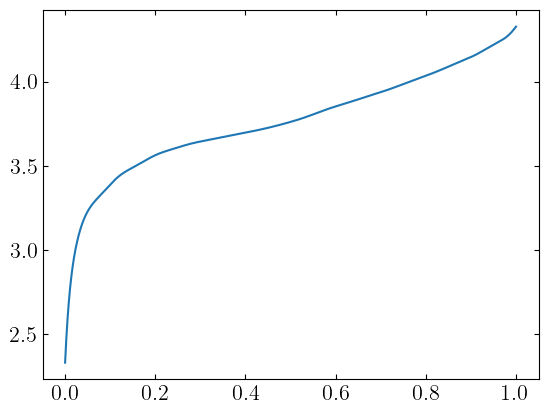

In [3]:
soc = np.linspace(0,1,int(2.5e4))
Ue = GP.soc_to_Ue(soc,GP_FIT) 
plt.plot(soc, Ue)

In [4]:
X_train = soc.reshape(-1,1)
Y_train = Ue.reshape(-1,1)

In [5]:
def print_models(df_model):
    for i in range(len(df_model)):
        print(f"Model {i}: Complexity={df_model['complexity'][i]}, Loss={df_model['loss'][i]}")
        print(f"Equation: {df_model['equation'][i]}\n")

def print_best_model(model, model_index = None):
    best = model.get_best()
    display(Math(f'\\LARGE {model.latex(model_index)}'))
    display(Math(r'\LARGE $x_0 = \mathrm{{c}}$-rate$'))
    display(Math(r'\LARGE $x_1 = \Delta u / L_{{tot}}$'))
    display(Math(r'\LARGE $x_2 = \mathrm{SOC}$'))
    print(f'Best model in symbolic form: {model.sympy()}\nLoss: {best["loss"]}\nBest model complexity: {best["complexity"]}')

In [6]:
# Parity plot
def pareto_plot(model):
    df_model = model.equations_
    best = model.get_best()
    plt.grid(True, which="both", ls="-", linewidth=0.5)
    plt.plot(df_model['complexity'], df_model['loss'], marker='o', linestyle='-', color=colors[0], label='Models')
    plt.plot(best['complexity'], best['loss'],'o', color=colors[1], label='Best Model')
    plt.xlabel('Complexity')
    plt.ylabel('Loss')
    plt.yscale('log')
    plt.title('Model Complexity vs Loss')
    plt.legend()
    plt.show()

def parity_plot(model, X_test = X_train, Y_test = Y_train):


    Y_pred = model.predict(X_test)
    plt.scatter(Y_test, Y_pred, color=colors[0],alpha = 0.5)
    plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'k--', lw=2)
    plt.xlabel(f'Actual $U_e$ [a.u.]')
    plt.ylabel(f'Predicted $U_e$ [a.u.]')
    plt.show()

def save_expressions(df_model, element):
    df_model.to_csv(f'model_{element}.csv', index=False)

# $U_{eq} = f_U(\mathrm{SOC})$

In [7]:
import_reload()
model_Ue = Param_symbol.run_symbolic_regression(X_train, Y_train, model = None,run_id = f'Ue_{RUN_ID}')

/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


In [8]:
df_model_Ue = model_Ue.equations_

In [9]:
print_models(df_model_Ue)

Model 0: Complexity=1, Loss=0.09608596
Equation: 3.7619348

Model 1: Complexity=3, Loss=0.010141226
Equation: x0 + 3.2619817

Model 2: Complexity=4, Loss=0.0094081415
Equation: sqrt(x0) + 3.0953088

Model 3: Complexity=5, Loss=0.005416778
Equation: sqrt(tan(x0)) + 3.0346813

Model 4: Complexity=6, Loss=0.0042200773
Equation: tan(sqrt(sqrt(x0))) + 2.6822007

Model 5: Complexity=7, Loss=0.0040439754
Equation: tan(sqrt(x0) + 5.2869024) + 4.1325016

Model 6: Complexity=8, Loss=0.0024200475
Equation: sqrt(sqrt(tan(x0)) * 2.5915027) + 2.4236622

Model 7: Complexity=9, Loss=0.00223797
Equation: sqrt((sqrt(sqrt(tan(x0))) * 11.692851) + 4.525669)

Model 8: Complexity=10, Loss=0.0004753038
Equation: cube((tan(sqrt(x0)) - x0) + -1.341328) + 4.74864

Model 9: Complexity=11, Loss=0.0004413926
Equation: tan((tan(sqrt(x0)) - sin(x0)) + -1.1959348) + 4.8358617

Model 10: Complexity=12, Loss=0.0001227233
Equation: tan(cos(x0) * ((sqrt(x0) - x0) + -1.2558268)) + 5.083132

Model 11: Complexity=13, Loss=9

In [10]:
print_best_model(model_Ue)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: tan((sqrt(x0) - x0 - 1.2558268)*cos(x0)) + 5.083132
Loss: 0.0001227233
Best model complexity: 12


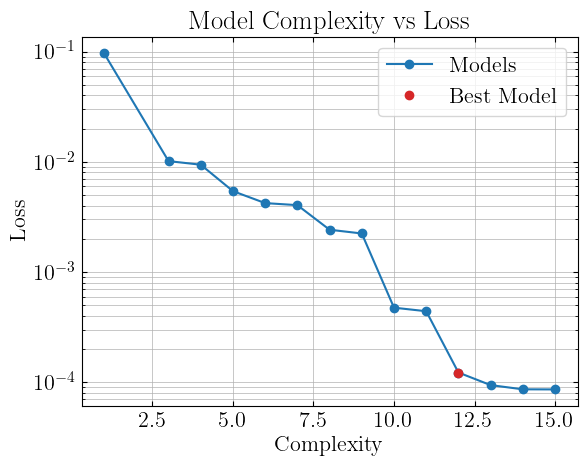

In [11]:
pareto_plot(model_Ue)

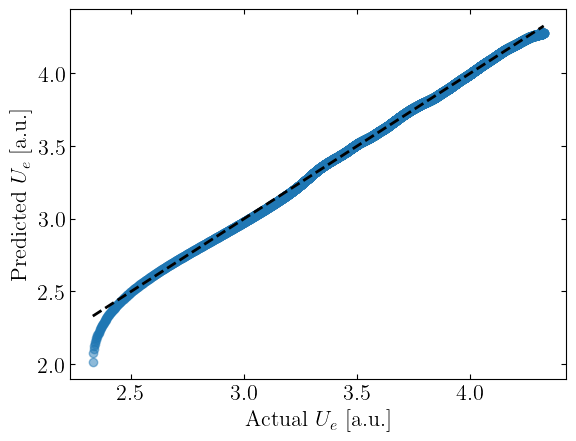

In [12]:
parity_plot(model_Ue)

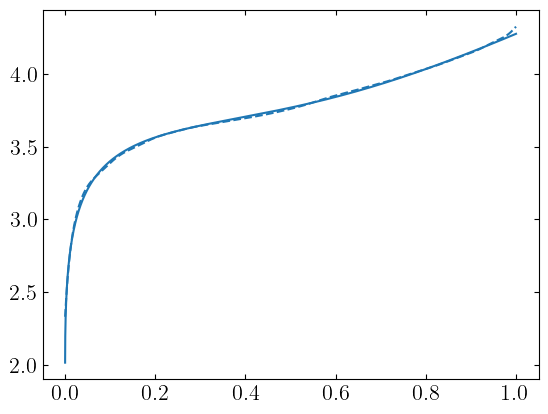

In [13]:
plt.plot(soc, model_Ue.predict(X_train), color=colors[0])
plt.plot(soc, Ue, color = colors[0],ls = '--')

In [14]:
# SAVE  = True
# if SAVE:
#     save_expressions(df_model_k,  f'k_{RUN_ID}')
#     save_expressions(df_model_R1, f'R1_{RUN_ID}')
#     save_expressions(df_model_C1, f'C1_{RUN_ID}')